In [1]:
import pandas as pd
import matplotlib.pyplot as plt

sessoes = pd.read_csv("../data/tratados/sessoes_condominio.csv")
sessoes["inicio"] = pd.to_datetime(sessoes["start_time"])

kwh_por_data = sessoes.groupby(sessoes["inicio"].dt.normalize())["energy_delivered_kwh"].sum()
calendario = pd.date_range(kwh_por_data.index.min(), kwh_por_data.index.max(), freq="D")
diario = kwh_por_data.reindex(calendario, fill_value=0).rename("kwh").to_frame()
diario["dia_semana"] = diario.index.dayofweek

print(diario.shape)
diario.head()

(378, 2)


,kwh,dia_semana
2025-09-17,14.60,2
2025-09-18,7.99,3
2025-09-19,7.79,4
2025-09-20,0.00,5
2025-09-21,8.44,6


In [2]:
data_corte = pd.Timestamp("2026-06-01")
treino = diario[diario.index < data_corte]
teste = diario[diario.index >= data_corte]

print("Treino:", treino.index.min().date(), "até", treino.index.max().date(), "-", len(treino), "dias")
print("Teste: ", teste.index.min().date(), "até", teste.index.max().date(), "-", len(teste), "dias")

Treino: 2025-09-17 até 2026-05-31 - 257 dias
Teste:  2026-06-01 até 2026-09-29 - 121 dias


In [3]:
media_treino = treino.groupby("dia_semana")["kwh"].mean()
print(media_treino.round(2))

teste = teste.copy()
teste["previsao_base"] = teste["dia_semana"].map(media_treino)
teste["erro_base"] = (teste["kwh"] - teste["previsao_base"]).abs()
mae_base = teste["erro_base"].mean()

media_geral = treino["kwh"].mean()
mae_media_geral = (teste["kwh"] - media_geral).abs().mean()

print("kWh médio por dia no teste:", round(teste["kwh"].mean(), 2))
print("Erro (MAE), média por dia da semana:", round(mae_base, 2), "kWh")
print("Erro (MAE), média geral:", round(mae_media_geral, 2), "kWh")

dia_semana
0    4.53
1    5.02
2    6.40
3    5.81
4    4.00
5    1.96
6    7.41
Name: kwh, dtype: float64
kWh médio por dia no teste: 4.9
Erro (MAE), média por dia da semana: 4.3 kWh
Erro (MAE), média geral: 4.51 kWh


In [4]:
teste["teve_recarga"] = teste["kwh"] > 0

resumo = teste.groupby("teve_recarga").agg(
    dias=("kwh", "count"),
    erro_medio=("erro_base", "mean")
).round(2)

print(resumo)
print("Proporção de dias com recarga no teste:", round(teste["teve_recarga"].mean(), 2))

              dias  erro_medio
teve_recarga                  
False           54        4.79
True            67        3.90
Proporção de dias com recarga no teste: 0.55


In [5]:
diario["kwh_ontem"] = diario["kwh"].shift(1)
diario["carregou_ontem"] = diario["kwh_ontem"] > 0
diario["carregou_hoje"] = diario["kwh"] > 0

base_treino = diario[diario.index < data_corte].iloc[1:]

print(base_treino.groupby("carregou_ontem")["carregou_hoje"].agg(["count", "mean"]).round(2))
print(base_treino.groupby("carregou_ontem")["kwh"].mean().round(2))

                count  mean
carregou_ontem             
False              95  0.47
True              161  0.72
carregou_ontem
False    5.01
True     4.97
Name: kwh, dtype: float64


In [6]:
com_recarga = base_treino[base_treino["carregou_hoje"]]
print(com_recarga.groupby("carregou_ontem")["kwh"].agg(["count", "mean", "median"]).round(2))

                count   mean  median
carregou_ontem                      
False              45  10.57   10.44
True              116   6.89    5.74


In [7]:
treino2 = diario[diario.index < data_corte].iloc[1:].copy()
treino2["sabado"] = treino2["dia_semana"] == 5

regra_A = treino2.groupby("carregou_ontem")["kwh"].median()
regra_B = treino2.groupby(["sabado", "carregou_ontem"])["kwh"].median()

print(regra_A.round(2))
print(regra_B.round(2))

carregou_ontem
False    0.00
True     5.14
Name: kwh, dtype: float64
sabado  carregou_ontem
False   False             4.82
        True              5.25
True    False             0.00
        True              0.00
Name: kwh, dtype: float64


In [8]:
teste3 = diario[diario.index >= data_corte].copy()
teste3["sabado"] = teste3["dia_semana"] == 5

previsao_A = teste3["carregou_ontem"].map(regra_A)
previsao_B = pd.Series(
    [regra_B[(s, o)] for s, o in zip(teste3["sabado"], teste3["carregou_ontem"])],
    index=teste3.index
)

mae_A = (teste3["kwh"] - previsao_A).abs().mean()
mae_B = (teste3["kwh"] - previsao_B).abs().mean()

print("MAE linha de base (dia da semana):", round(mae_base, 2))
print("MAE regra A (ontem):", round(mae_A, 2))
print("MAE regra B (ontem + sábado):", round(mae_B, 2))

MAE linha de base (dia da semana): 4.3
MAE regra A (ontem): 5.54
MAE regra B (ontem + sábado): 4.24


In [9]:
mediana_treino = treino.groupby("dia_semana")["kwh"].median()
print(mediana_treino.round(2))

previsao_mediana = teste["dia_semana"].map(mediana_treino)
mae_mediana = (teste["kwh"] - previsao_mediana).abs().mean()
print("MAE mediana por dia da semana:", round(mae_mediana, 2))

dia_semana
0    5.08
1    5.48
2    5.66
3    6.25
4    4.62
5    0.00
6    7.64
Name: kwh, dtype: float64
MAE mediana por dia da semana: 4.15


In [10]:
diario["kwh_semana_passada"] = diario["kwh"].shift(7)
teste_n = diario[diario.index >= data_corte]
mae_ingenuo = (teste_n["kwh"] - teste_n["kwh_semana_passada"]).abs().mean()
print("MAE ingênuo (mesmo dia da semana passada):", round(mae_ingenuo, 2))

erro_mediana = (teste["kwh"] - previsao_mediana).abs()
print(erro_mediana.groupby(teste["dia_semana"]).mean().round(2))

MAE ingênuo (mesmo dia da semana passada): 5.78
dia_semana
0    3.94
1    4.28
2    4.88
3    5.44
4    4.07
5    1.79
6    4.65
dtype: float64


In [11]:
print(sessoes.columns.tolist())

['session_id', 'user_id', 'user_name', 'unit', 'vehicle_model', 'battery_capacity_kwh', 'start_time', 'end_time', 'duration_minutes', 'energy_delivered_kwh', 'power_peak_kw', 'voltage_v', 'current_a', 'cost_rate_per_kwh', 'total_cost_brl', 'status', 'inicio']


count    242.00
mean       2.05
std        0.43
min        0.93
25%        1.70
50%        2.05
75%        2.27
max        3.78
Name: kw_medio, dtype: float64
kw_medio
0.9     1
1.1     1
1.2     1
1.4     2
1.5    17
1.6    28
1.7    23
1.8    12
1.9    15
2.0    20
2.1    21
2.2    33
2.3    21
2.4    16
2.5     9
2.6     3
2.9     5
3.0    13
3.8     1
Name: count, dtype: int64


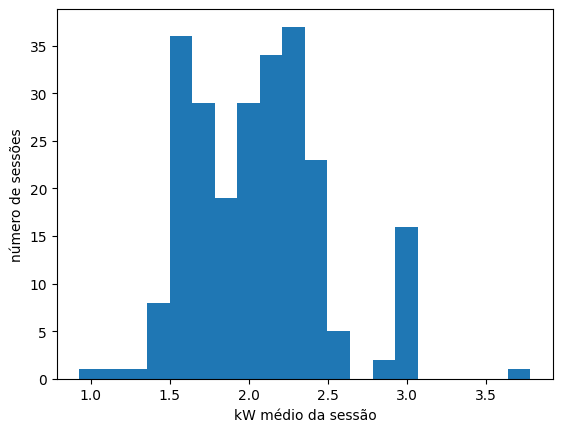

In [12]:
sessoes["fim"] = pd.to_datetime(sessoes["end_time"])
sessoes["horas"] = (sessoes["fim"] - sessoes["inicio"]).dt.total_seconds() / 3600
validas = sessoes[sessoes["horas"] > 0].copy()
validas["kw_medio"] = validas["energy_delivered_kwh"] / validas["horas"]

print(validas["kw_medio"].describe().round(2))
print(validas["kw_medio"].round(1).value_counts().sort_index())

validas["kw_medio"].plot(kind="hist", bins=20)
plt.xlabel("kW médio da sessão")
plt.ylabel("número de sessões")
plt.show()

In [13]:
def avaliar(corte):
    corte = pd.Timestamp(corte)
    tr = diario[diario.index < corte]
    te = diario[diario.index >= corte]

    media_geral = tr["kwh"].mean()
    media_dia = te["dia_semana"].map(tr.groupby("dia_semana")["kwh"].mean())
    mediana_dia = te["dia_semana"].map(tr.groupby("dia_semana")["kwh"].median())
    ingenuo = diario["kwh"].shift(7).loc[te.index]

    return {
        "dias_teste": len(te),
        "media_geral": (te["kwh"] - media_geral).abs().mean(),
        "media_por_dia": (te["kwh"] - media_dia).abs().mean(),
        "mediana_por_dia": (te["kwh"] - mediana_dia).abs().mean(),
        "ingenuo": (te["kwh"] - ingenuo).abs().mean(),
    }

cortes = ["2026-03-01", "2026-05-01", "2026-06-01", "2026-07-01"]
tabela = pd.DataFrame({c: avaliar(c) for c in cortes}).T

modelos = ["media_geral", "media_por_dia", "mediana_por_dia", "ingenuo"]
tabela["melhor"] = tabela[modelos].idxmin(axis=1)
print(tabela.round(2))

            dias_teste  media_geral  media_por_dia  mediana_por_dia  ingenuo  \
2026-03-01       213.0         4.24           4.06             3.94     5.24   
2026-05-01       152.0         4.50           4.21             4.13     5.59   
2026-06-01       121.0         4.51           4.30             4.15     5.78   
2026-07-01        91.0         4.58           4.38             4.23     6.24   

                     melhor  
2026-03-01  mediana_por_dia  
2026-05-01  mediana_por_dia  
2026-06-01  mediana_por_dia  
2026-07-01  mediana_por_dia  


In [14]:
med_treino = treino.groupby("dia_semana")["kwh"].median()
med_todos = diario.groupby("dia_semana")["kwh"].median()

comparacao = pd.DataFrame({"so_treino": med_treino, "todos_os_dias": med_todos})
comparacao["diferenca"] = comparacao["todos_os_dias"] - comparacao["so_treino"]
print(comparacao.round(2))


            so_treino  todos_os_dias  diferenca
dia_semana                                     
0                5.08           5.24       0.16
1                5.48           5.48       0.00
2                5.66           5.76       0.10
3                6.25           6.04      -0.21
4                4.62           4.61      -0.01
5                0.00           0.00       0.00
6                7.64           6.72      -0.92


In [15]:
faixa = treino.groupby("dia_semana")["kwh"].quantile([0.25, 0.75]).unstack()
faixa.columns = ["p25", "p75"]

te = teste[["kwh", "dia_semana"]].join(faixa, on="dia_semana")
te["dentro"] = (te["kwh"] >= te["p25"]) & (te["kwh"] <= te["p75"])

print(faixa.round(2))
print("Proporção de dias do teste dentro da faixa:", round(te["dentro"].mean(), 2))
print(te.groupby("dia_semana")["dentro"].mean().round(2))

             p25    p75
dia_semana             
0           0.00   7.80
1           0.00   7.86
2           4.70  10.00
3           1.01   8.48
4           0.00   5.46
5           0.00   0.00
6           0.00  11.70
Proporção de dias do teste dentro da faixa: 0.57
dia_semana
0    0.67
1    0.67
2    0.35
3    0.06
4    0.65
5    0.71
6    0.88
Name: dentro, dtype: float64


In [16]:
dias_treino = treino.copy()
dias_treino["recarga"] = dias_treino["kwh"] > 0
dias_teste = teste.copy()
dias_teste["recarga"] = dias_teste["kwh"] > 0

chance_treino = dias_treino.groupby("dia_semana")["recarga"].mean()
chance_teste = dias_teste.groupby("dia_semana")["recarga"].mean()
tamanho_treino = dias_treino[dias_treino["recarga"]].groupby("dia_semana")["kwh"].median()
tamanho_teste = dias_teste[dias_teste["recarga"]].groupby("dia_semana")["kwh"].median()

quadro = pd.DataFrame({
    "chance_treino": chance_treino,
    "chance_teste": chance_teste,
    "tamanho_treino": tamanho_treino,
    "tamanho_teste": tamanho_teste,
})
print(quadro.round(2))

            chance_treino  chance_teste  tamanho_treino  tamanho_teste
dia_semana                                                            
0                    0.67          0.78            5.75           7.46
1                    0.67          0.56            6.20           8.89
2                    0.76          0.59            8.32           9.76
3                    0.76          0.47            7.66          10.05
4                    0.59          0.59            5.26           7.94
5                    0.24          0.29            7.82           7.08
6                    0.73          0.59           10.44           9.03


In [17]:
modelo_final = diario.groupby("dia_semana")["kwh"].median()

print(modelo_final.round(2))
print("Dias usados:", len(diario), "| de", diario.index.min().date(), "a", diario.index.max().date())
print("Erro esperado (MAE de validação):", round(mae_mediana, 2), "kWh por dia")

dia_semana
0    5.24
1    5.48
2    5.76
3    6.04
4    4.61
5    0.00
6    6.72
Name: kwh, dtype: float64
Dias usados: 378 | de 2025-09-17 a 2026-09-29
Erro esperado (MAE de validação): 4.15 kWh por dia


In [18]:
resumo = pd.DataFrame({
    "modelo": [
        "Média geral",
        "Ingênuo (mesmo dia da semana passada)",
        "Regra A (ontem)",
        "Média por dia da semana (linha de base)",
        "Regra B (ontem + sábado)",
        "Mediana por dia da semana",
    ],
    "mae_kwh": [mae_media_geral, mae_ingenuo, mae_A, mae_base, mae_B, mae_mediana],
})
resumo["ganho_sobre_base"] = mae_base - resumo["mae_kwh"]
print(resumo.sort_values("mae_kwh").round(2).to_string(index=False))

                                 modelo  mae_kwh  ganho_sobre_base
              Mediana por dia da semana     4.15              0.15
               Regra B (ontem + sábado)     4.24              0.06
Média por dia da semana (linha de base)     4.30              0.00
                            Média geral     4.51             -0.21
                        Regra A (ontem)     5.54             -1.25
  Ingênuo (mesmo dia da semana passada)     5.78             -1.48


## Conclusões

- Validação por data: treino até 31/05/2026 (257 dias) e teste de 01/06 a 29/09/2026 (121 dias).
- A mediana de kWh por dia da semana teve o menor erro (4,15 kWh por dia) e ficou em primeiro em quatro datas de corte diferentes (01/03, 01/05, 01/06 e 01/07). Os quatro testes usam janelas que se sobrepõem, então não são independentes.
- O ganho sobre a linha de base (média por dia da semana, 4,30) é pequeno, de 0,1 a 0,2 kWh. O ingênuo (5,78) e a regra baseada em "ontem" (5,54) ficaram piores.
- O erro ainda é alto frente à média de 4,9 kWh por dia: a demanda diária é intermitente (dias sem recarga ou com recarga grande). O modelo estima o dia típico e não prevê picos.
- Modelo final: as 7 medianas calculadas com os 378 dias. Só o domingo mudou de forma relevante em relação ao modelo treinado só até maio (7,64 para 6,72).
- A faixa entre o percentil 25 e o 75 não se sustentou (de 6% a 88% dos dias dentro dela, conforme o dia da semana), por isso não será usada.
- Limitação: todas as sessões vêm de um único cartão RFID, então o modelo representa o padrão desse carregador e cartão, não o de um condomínio.